In [45]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from convenience_functions import show_image
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from astropy.modeling import models, fitting
from astropy.stats import sigma_clipped_stats

In [20]:
# Load the FITS file
filename = "/Users/applestore/exo-observe/Data/WASP-12b-20150209/calibrated/c13a_150210_023600_ori_Trim_only_v4_calibrated_darkandflat.fits"
hdul = fits.open(filename)
image_data = hdul[0].data
hdul.close()

## Display the image
#show_image(image_data, cmap='gray', percl=90)


PIXXMIT                        / Number of pixels returned per ADC go            [astropy.io.fits.card]
PIXOFFST                       / Valid pixel offset within ADC go                [astropy.io.fits.card]


In [22]:
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)

In [23]:
# Within convenience_functions.py:

import matplotlib.pyplot as plt
import numpy as np

def show_image(image_data, cmap='gray', percl=90, fig=None, ax=None):
    """Displays an image with percentile contrast scaling using matplotlib.

    Args:
        image_data (numpy.ndarray): The image data to display.
        cmap (str, optional): The colormap to use. Defaults to 'gray'.
        percl (float, optional): The percentile for contrast scaling. Defaults to 90.
        fig (matplotlib.figure.Figure, optional): The figure object to plot on. Defaults to None.
        ax (matplotlib.axes._axes.Axes, optional): The axes object to plot on.  If None, a new one is created.
    """
    vmin, vmax = np.percentile(image_data, (100 - percl, percl))

    if ax is None and fig is None:
        fig, ax = plt.subplots(1) # Create figure and axes if neither are provided
    elif ax is None and fig is not None:
        ax = fig.add_subplot(111) # Add subplot to existing figure if only fig is provided
    elif fig is None and ax is not None:
        fig = ax.figure # Get the figure from the axes object.


    ax.imshow(image_data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')  #Crucially uses ax.imshow
    ax.axis('off') # Turn off axis labels

    return fig, ax  # Return both figure and axes object

Brightest source found at: (202.88, 429.49)


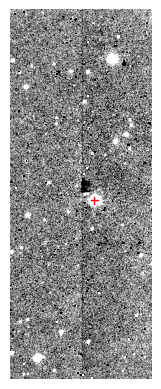

In [25]:

brightest_star = sources[np.argmax(sources['flux'])]

x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']

print(f"Brightest source found at: ({x_centroid:.2f}, {y_centroid:.2f})")

# Display the image with a crosshair
fig, ax = plt.subplots(1)  # Create a figure and an axes object
fig, ax = show_image(image_data, cmap='gray', percl=90, fig=fig, ax=ax)  # Pass the axes to show_image

# Add crosshair
crosshair_size = 9  # Adjust for desired crosshair size

ax.plot([x_centroid - crosshair_size, x_centroid + crosshair_size], [y_centroid, y_centroid], 'r-', linewidth=1)  # Horizontal line
ax.plot([x_centroid, x_centroid], [y_centroid - crosshair_size, y_centroid + crosshair_size], 'r-', linewidth=1)  # Vertical line

plt.show() # explicitly show the plot

In [29]:
Size_of_the_cutout_region=30
size = Size_of_the_cutout_region
x_min, x_max = int(x_centroid - size//2), int(x_centroid + size//2)
y_min, y_max = int(y_centroid - size//2), int(y_centroid + size//2)
cutout = image_data[y_min:y_max, x_min:x_max]
# Create coordinate grids
y, x = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# Define a 2D Gaussian model
g_init = models.Gaussian2D(amplitude=cutout.max(), 
                           x_mean=size//2, y_mean=size//2,
                           x_stddev=3, y_stddev=3)

# Fit the model to the cutout data
fitter = fitting.LevMarLSQFitter()
g_fit = fitter(g_init, x, y, cutout)

# Calculate FWHM using the Gaussian relation: FWHM = 2.355 * sigma
fwhm_x = 2.355 * g_fit.x_stddev.value
fwhm_y = 2.355 * g_fit.y_stddev.value

print(f"FWHM_x: {fwhm_x:.2f} pixels, FWHM_y: {fwhm_y:.2f} pixels")

FWHM_x: 3.71 pixels, FWHM_y: 3.59 pixels


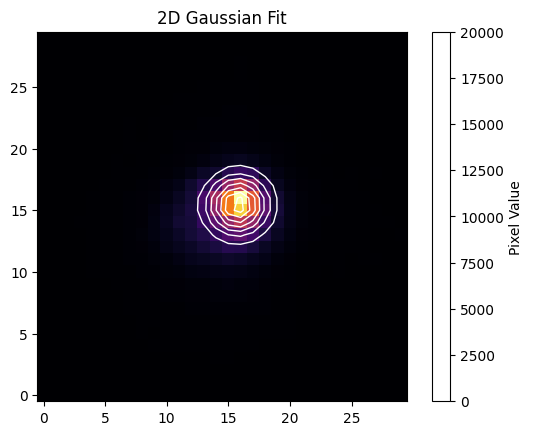

Average FWHM: 0.19 arcsec


In [30]:
plt.imshow(cutout, cmap='inferno', origin='lower')
plt.contour(g_fit(x, y), colors='white', linewidths=1)
plt.title("2D Gaussian Fit")
plt.colorbar(label="Pixel Value")
plt.show()

fwhm_avg = (((fwhm_x + fwhm_y) / 2)*0.051)
print(f"Average FWHM: {fwhm_avg:.2f} arcsec")

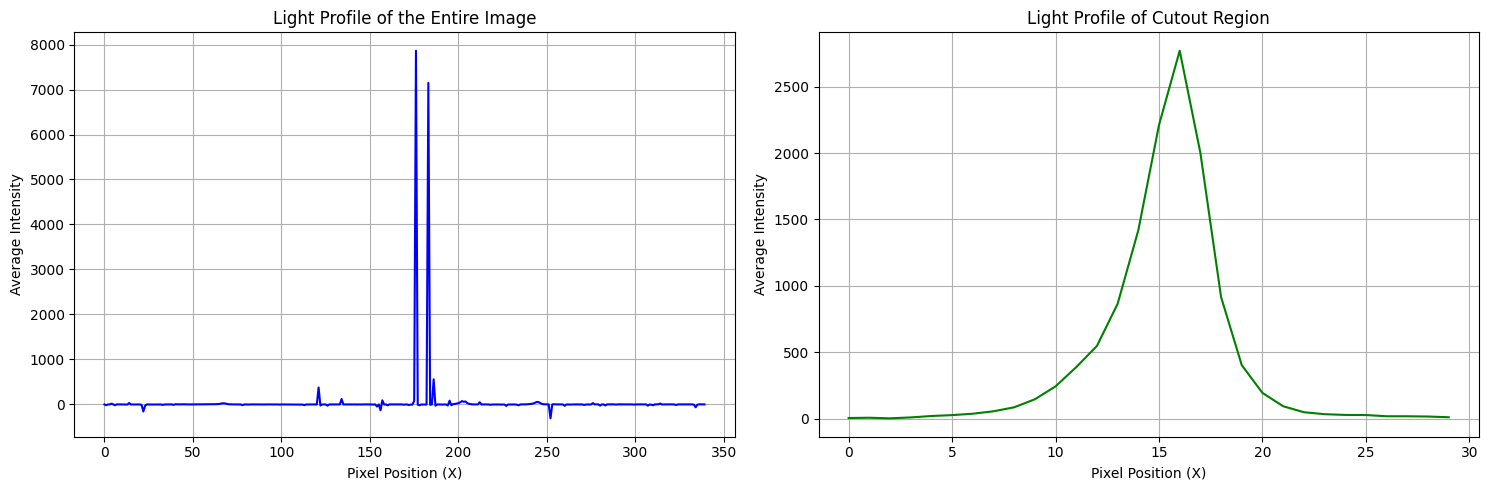

In [41]:
### Looking at the light Profile ###

# Calculate background statistics
mean_full, median_full, std_full = sigma_clipped_stats(image_data, sigma=3.0)

# Subtract the median to remove the background
data_sub_full = image_data - median_full

# Calculate the light profile by averaging along the y-axis
light_profile_full = np.mean(data_sub_full, axis=0)

# --- Code for Cutout Profile (Second Code) ---
size = Size_of_the_cutout_region
x_min, x_max = int(x_centroid - size//2), int(x_centroid + size//2)
y_min, y_max = int(y_centroid - size//2), int(y_centroid + size//2)
data_sub_cutout = image_data[y_min:y_max, x_min:x_max]
light_profile_cutout = np.mean(data_sub_cutout, axis=0)

# --- Create the Figure with Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # 1 row, 2 columns of subplots

# Plot the Full Image Profile
axes[0].plot(light_profile_full, 'b-')
axes[0].set_xlabel('Pixel Position (X)')
axes[0].set_ylabel('Average Intensity')
axes[0].set_title('Light Profile of the Entire Image')
axes[0].grid()

# Plot the Cutout Profile
axes[1].plot(light_profile_cutout, 'g-')  # Use a different color (green)
axes[1].set_xlabel('Pixel Position (X)')
axes[1].set_ylabel('Average Intensity')
axes[1].set_title('Light Profile of Cutout Region')
axes[1].grid()

plt.tight_layout()  # Adjust spacing to prevent labels from overlapping
plt.show()

In [52]:
#x
#y
# The numbers show how the average brightness changes as you move across the cutout region,
# from one side to the other.

light_profile

array([   6.66958659,    8.62276646,    4.12367876,   11.04710388,
         21.76038143,   28.4082747 ,   38.97238698,   57.16353998,
         87.17004684,  147.3651134 ,  244.56704777,  389.28306309,
        548.66079295,  865.42687137, 1418.65612539, 2210.69661112,
       2769.73155172, 2001.12878888,  916.3212734 ,  403.97814721,
        195.32758821,   95.08550564,   50.26712127,   35.31718722,
         29.82015695,   28.96959275,   19.83750096,   19.61626517,
         17.77258434,   12.36935325])

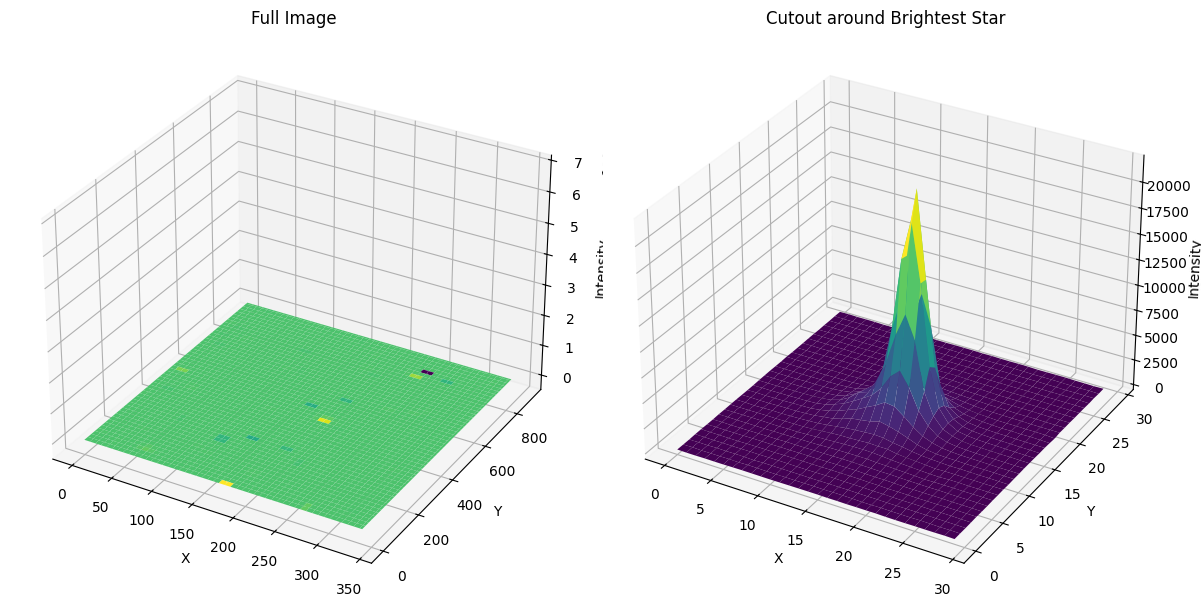

In [51]:

# --- Plot 1: Full Image ---
y1, x1 = np.mgrid[:image_data.shape[0], :image_data.shape[1]]

# --- Plot 2: Cutout around Brightest Star ---
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)
if sources is not None:
    brightest_star = sources[np.argmax(sources['flux'])]
    x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']
    size = 60
    x_min, x_max = int(x_centroid - size//4), int(x_centroid + size//4)
    y_min, y_max = int(y_centroid - size//4), int(y_centroid + size//4)
    cutout = image_data[y_min:y_max, x_min:x_max]
    y2, x2 = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    # --- Create the Figure with Subplots ---
    fig = plt.figure(figsize=(12, 6))  # Adjust size as needed

    # Plot 1: Full Image
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(x1, y1, image_data, cmap='viridis')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Intensity')
    ax1.set_title('Full Image')

    # Plot 2: Cutout
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(x2, y2, cutout, cmap='viridis')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Intensity')
    ax2.set_title('Cutout around Brightest Star')

    plt.tight_layout()
    plt.show()
else:
    print("No stars found in the image.")